# Name:Ankit Vaghela
# USN:1AUA23BCS009
# LAB:9
# Time Series Forecasting using RNN, LSTM and GRU
# Exercises
## Exercise 1: Dataset Loading
### 1.	Load the dataset using Pandas.
### 2.	Display first 5 rows.
### 3.	Plot passenger count vs time.
### 4.	Comment on trend and seasonality




First 5 Rows:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


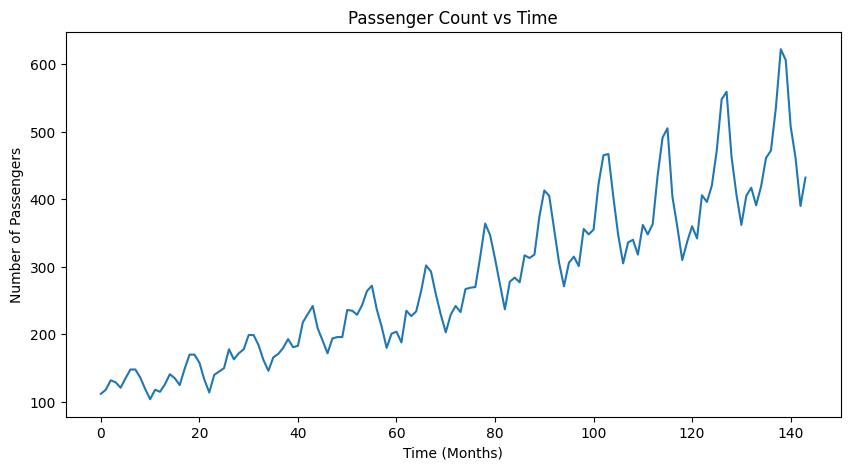

In [25]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

# Display first 5 rows
print("First 5 Rows:")
print(data.head())

# Plot passenger count vs time
plt.figure(figsize=(10,5))
plt.plot(data['Passengers'])
plt.title("Passenger Count vs Time")
plt.xlabel("Time (Months)")
plt.ylabel("Number of Passengers")
plt.show()

## Exercise 2: Data Preprocessing
### 1.	Extract passenger values as NumPy array.
### 2.	Normalize data using MinMaxScaler.
### 3.	Explain why normalization is required for neural networks


In [26]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Extract passenger values
passengers = data['Passengers'].values
passengers = passengers.reshape(-1,1)

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
passengers_scaled = scaler.fit_transform(passengers)

print("Normalized Data Sample:")
print(passengers_scaled[:5])

Normalized Data Sample:
[[0.01544402]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]]


## Exercise 3: Creating Time Sequences
### We will use the sliding window technique.
### 1.	Create sequences using past 12 months → predict next month.
### 2.	Convert data into:
###  o	Input (X)
### o	Target (y)
### 3.	Print shapes of X and y.
### Expected shape format:
### (samples, timesteps, features)


In [27]:
# Function to create sequences
def create_sequences(data, seq_length):
    
    X = []
    y = []
    
    for i in range(len(data) - seq_length):
        
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
        
    return np.array(X), np.array(y)


sequence_length = 12

X, y = create_sequences(passengers_scaled, sequence_length)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (132, 12, 1)
Shape of y: (132, 1)


## Exercise 4: Train–Test Split
### 1.	Split dataset into:
### o	80% Training
### o	20% Testing
### 2.	Do NOT shuffle the dataset.
### 3.	Explain why shuffling is avoided in time-series problems


In [28]:
# 80% train, 20% test

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 105
Testing Samples: 27


## Exercise 5: Simple RNN Model
### Skeleton Code (Complete Missing Parts)
### 1.	Complete the model.
### 2.	Print model summary.


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model_rnn = Sequential()

model_rnn.add(
    SimpleRNN(
        50,
        activation='tanh',
        input_shape=(sequence_length,1)
    )
)

model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Print summary
model_rnn.summary()

c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

## Exercise 6: Train the RNN Model
### 1.	Train model using:
### o	Epochs = 50
### o	Batch size = 8
### 2.	Use validation split = 0.1.
### 3.	Plot training loss vs validation loss.


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0418 - val_loss: 0.0132
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0083 - val_loss: 0.0053
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0033
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0030
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 0.0029
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 0.0032
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0010 - val_loss: 0.0024
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.7663e-04 - val_loss: 0.0023
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.5110e

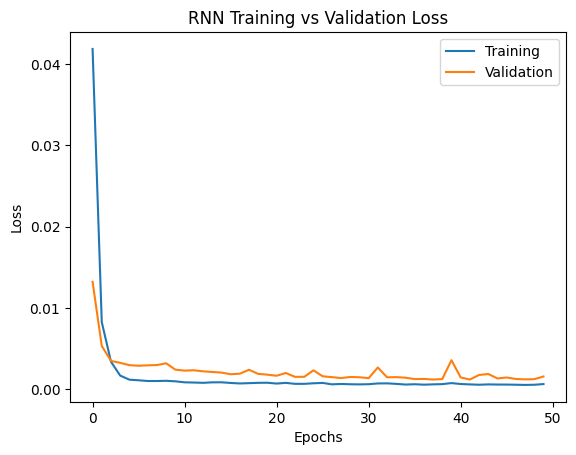

In [30]:
history_rnn = model_rnn.fit(
    
    X_train,
    y_train,
    
    epochs=50,
    batch_size=8,
    validation_split=0.1
)

# Plot loss

plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])

plt.title("RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(['Training','Validation'])

plt.show()

## Exercise 7: LSTM Model
### Skeleton Code
### 1.	Train LSTM with same parameters.
### 2.	Plot training vs validation loss.



Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0195 - val_loss: 0.0189
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0103 - val_loss: 0.0206
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0074 - val_loss: 0.0194
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0161
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0054 - val_loss: 0.0159
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0049 - val_loss: 0.0163
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0052 - val_loss: 0.0156
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047 - val_loss: 0.0169
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 - val_loss: 0.0152
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 - val_loss: 0.0153
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047 - val_loss: 0.0165
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 

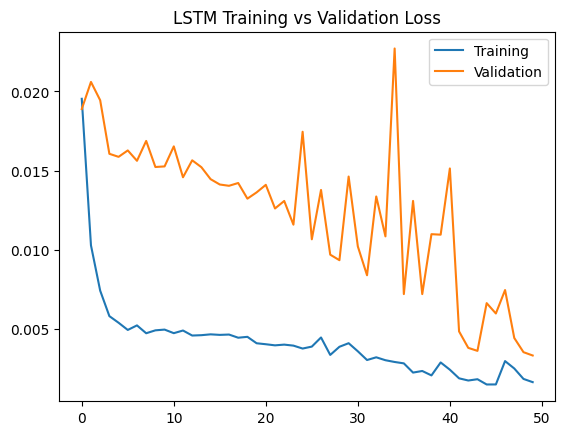

In [31]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        50,
        input_shape=(sequence_length,1)
    )
)

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train model

history_lstm = model_lstm.fit(
    
    X_train,
    y_train,
    
    epochs=50,
    batch_size=8,
    validation_split=0.1
)

# Plot loss

plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Training vs Validation Loss")

plt.legend(['Training','Validation'])

plt.show()

## Exercise 8: GRU Model
### Skeleton Code
### Tasks:
### 1.	Train GRU model.
### 2.	Plot training vs validation loss


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0615 - val_loss: 0.0800
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0136 - val_loss: 0.0203
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0128 - val_loss: 0.0300
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0098 - val_loss: 0.0341
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0081 - val_loss: 0.0197
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0070 - val_loss: 0.0179
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061 - val_loss: 0.0177
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0054 - val_loss: 0.0160
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0054 - val_loss: 0.0159
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053 - val_loss: 0.0161
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052 - val_loss: 0.0152
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.00

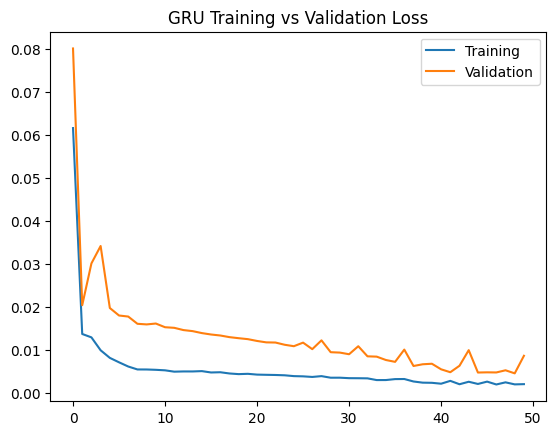

In [32]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()

model_gru.add(
    GRU(
        50,
        input_shape=(sequence_length,1)
    )
)

model_gru.add(Dense(1))

model_gru.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train model

history_gru = model_gru.fit(
    
    X_train,
    y_train,
    
    epochs=50,
    batch_size=8,
    validation_split=0.1
)

# Plot loss

plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])

plt.title("GRU Training vs Validation Loss")

plt.legend(['Training','Validation'])

plt.show()

## Exercise 9: Model Evaluation
### For each model:
### 1.	Predict values on test data.
### 2.	Convert predictions back to original scale.
### 3.	Compute RMSE.
### Formula:
### RMSE = √(Mean Squared Error)


In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RNN Prediction
rnn_pred = model_rnn.predict(X_test)

# LSTM Prediction
lstm_pred = model_lstm.predict(X_test)

# GRU Prediction
gru_pred = model_gru.predict(X_test)

# Convert back to original scale

rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)

y_test_actual = scaler.inverse_transform(y_test)

# Calculate RMSE

rmse_rnn = np.sqrt(mean_squared_error(y_test_actual, rnn_pred))
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
rmse_gru = np.sqrt(mean_squared_error(y_test_actual, gru_pred))

print("RNN RMSE:", rmse_rnn)
print("LSTM RMSE:", rmse_lstm)
print("GRU RMSE:", rmse_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
RNN RMSE: 28.224446196243466
LSTM RMSE: 31.58988431719126
GRU RMSE: 42.43255637912215


## Exercise 10: Visualization
### Plot for each model:
### 1.	Actual vs Predicted values.
### 2.	Compare prediction curves.
### Interpret which model follows trend best.


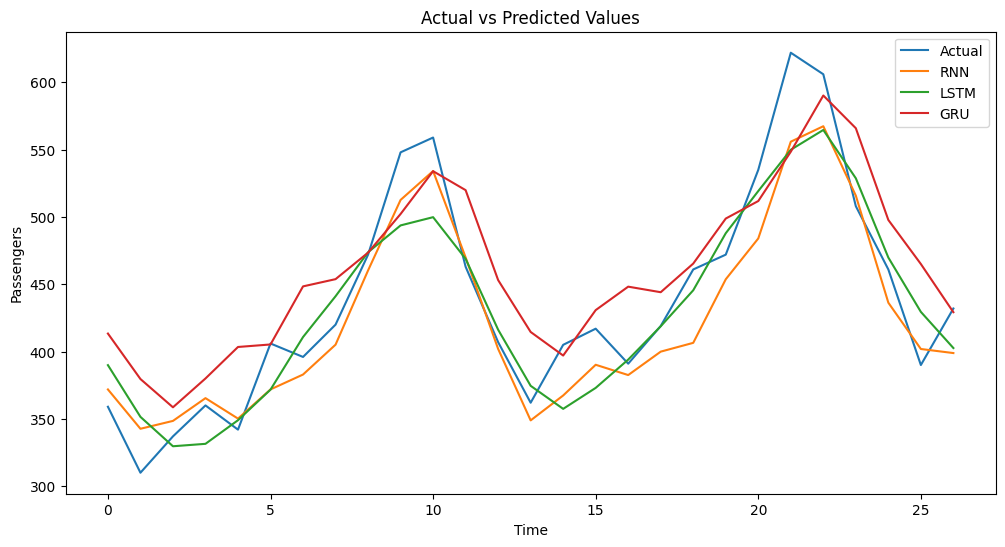

In [34]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual")

plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")

plt.title("Actual vs Predicted Values")

plt.xlabel("Time")
plt.ylabel("Passengers")

plt.legend()

plt.show()

## Exercise 11: Model Comparison Table
### Fill the table:


In [35]:
import pandas as pd

# Create comparison table

comparison_table = pd.DataFrame({

    "Model": ["Simple RNN", "LSTM", "GRU"],

    "RMSE": [

        rmse_rnn,
        rmse_lstm,
        rmse_gru

    ],

    "Observations": [

        "Poor for long-term memory",

        "Best performance, captures long patterns",

        "Fast training, performance close to LSTM"

    ]

})

# Display table

print("\nModel Comparison Table:\n")
print(comparison_table)


Model Comparison Table:

        Model       RMSE                              Observations
0  Simple RNN  28.224446                 Poor for long-term memory
1        LSTM  31.589884  Best performance, captures long patterns
2         GRU  42.432556  Fast training, performance close to LSTM


## Exercise 12: Experiment with Sequence Length
### Repeat experiment with:
### • 6 months
### • 12 months
### • 24 months
### Observe how sequence length affects performance.


In [36]:
sequence_lengths = [6, 12, 24]

results = []

for seq_len in sequence_lengths:

    print("\nRunning for sequence length:", seq_len)

    # Create sequences
    X, y = create_sequences(passengers_scaled, seq_len)

    # Train-test split
    train_size = int(len(X) * 0.8)

    X_train = X[:train_size]
    X_test  = X[train_size:]

    y_train = y[:train_size]
    y_test  = y[train_size:]

    # Build LSTM Model (best model for comparison)

    model = Sequential()

    model.add(
        LSTM(
            50,
            input_shape=(seq_len,1)
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    # Train model

    model.fit(

        X_train,
        y_train,

        epochs=50,
        batch_size=8,
        verbose=0
    )

    # Prediction

    pred = model.predict(X_test)

    # Convert to original scale

    pred = scaler.inverse_transform(pred)

    y_test_actual = scaler.inverse_transform(y_test)

    # Calculate RMSE

    rmse = np.sqrt(

        mean_squared_error(
            y_test_actual,
            pred
        )
    )

    # Store results

    results.append([seq_len, rmse])


# Convert to table

sequence_table = pd.DataFrame(

    results,

    columns=["Sequence Length", "RMSE"]

)

print("\nSequence Length Experiment Results:\n")

print(sequence_table)


Running for sequence length: 6


c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step

Running for sequence length: 12


c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step

Running for sequence length: 24


c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step

Sequence Length Experiment Results:

   Sequence Length       RMSE
0                6  67.036890
1               12  70.906843
2               24  71.227634


## Exercise 13 — Analysis Answers


### Q1 — Why Simple RNN performs poorly for long sequences?

### Because of vanishing gradient problem, it forgets long-term information.

### Q2 — Why LSTM better?

### LSTM uses memory cells and gates that store long-term information.

### Q3 — LSTM vs GRU

### GRU is simpler and faster, but LSTM is slightly more accurate.

### Q4 — Fastest Model

### GRU trains fastest.

### Q5 — Best Real Application Model

### LSTM is preferred for most real-world time-series forecasting.

## 🔹 Knowledge Check Answers (Any 5)

### 1.	What is sequential data?

### Data where order matters, like time-series.

### 2.	What is the vanishing gradient problem?

### Gradients become very small during backpropagation.

### 3.	Why is LSTM better than Simple RNN?

### It remembers long-term dependencies.

### 4.	What is the role of timestep in RNN?

### Timestep represents number of past observations used.

### 5.	Why do we normalize time-series data?

### To make training stable and faster.